In [70]:
import matplotlib.pyplot as plt  
import numpy as np               
import pandas as pd              
from scipy import stats          

# Data understanding

###  Leitura do dataset

In [71]:
listing = "dataset/listings.csv"
df = pd.read_csv(listing)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,48154,Precioso apartamento con wifi,219476,Antonio,LA SAIDIA,MORVEDRE,39.48375,-0.37502,Entire home/apt,83.0,3,197,2025-09-15,1.08,4,150,26,VT-41540-V
1,137143,PENTHOUSE ON FRONT LINE BEACH,670775,Maria De La Piedad,POBLATS DEL SUD,EL SALER,39.36335,-0.31932,Entire home/apt,390.0,10,1,2013-07-02,0.01,5,20,0,VT32745V
2,149715,1900 Style Valencian Beach Home for 10px,5947,Susana Barbara,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.46746,-0.32813,Entire home/apt,245.0,2,313,2025-09-15,1.81,1,287,41,ESFCTU000046025000580569000000000000000000VT-3...
3,165971,★ Architectural touch! ★,791187,Inés,EXTRAMURS,LA ROQUETA,39.46790,-0.38206,Entire home/apt,124.0,5,576,2025-09-03,3.34,8,106,46,VT-32757-V
4,182221,Apartments Calatrava City Valencia,1315567,Chiara,CAMINS AL GRAU,AIORA,39.46343,-0.34325,Entire home/apt,137.0,3,9,2025-03-17,0.07,1,176,1,VT-38755-V


In [72]:
#converter last_review para datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

df.describe(include="all").round(3)

### descrição inicial

In [73]:
quantiva_discretas = ["number_of_reviews_ltm", "number_of_reviews", "minimum_nights", "calculated_host_listings_count"]
quantiva_continuas = ["latitude", "longitude", "price", "reviews_per_month", ]



In [74]:
df[quantiva_continuas].describe(include="all").round(3)

,latitude,longitude,price,reviews_per_month
count,7844.000,7844.000,6979.000,6867.000
mean,39.467,-0.364,164.113,1.695
std,0.019,0.023,732.639,1.666
min,39.280,-0.426,8.000,0.010
25%,39.461,-0.380,71.000,0.470
50%,39.469,-0.371,102.000,1.170
75%,39.475,-0.344,140.000,2.490
max,39.546,-0.276,40000.000,37.710


In [75]:
#intervalo de variação (range),#ntervalo interquartis (IQR),assimetria, Curtose
for variavel in quantiva_discretas:
    print(f"Variável: {variavel}")
    print(f"Intervalo de variação: {df[variavel].max() - df[variavel].min()}")
    print(f"Intervalo interquartil: {(df[variavel].quantile(0.75) - df[variavel].quantile(0.25)).round(3)}")
    print(f"Assimetria: {df[variavel].skew().round(3)}")
    print(f"Curtose: {df[variavel].kurtosis().round(3)}")
    print("-" * 50)



Variável: number_of_reviews_ltm
Intervalo de variação: 367
Intervalo interquartil: 20.0
Assimetria: 2.868
Curtose: 25.877
--------------------------------------------------
Variável: number_of_reviews
Intervalo de variação: 935
Intervalo interquartil: 55.25
Assimetria: 3.038
Curtose: 11.98
--------------------------------------------------
Variável: minimum_nights
Intervalo de variação: 365
Intervalo interquartil: 4.0
Assimetria: 13.279
Curtose: 228.086
--------------------------------------------------
Variável: calculated_host_listings_count
Intervalo de variação: 102
Intervalo interquartil: 10.0
Assimetria: 2.504
Curtose: 5.893
--------------------------------------------------


In [76]:
for variavel in quantiva_continuas:
    print(f"Variável: {variavel}")
    print(f"Intervalo de variação: {df[variavel].max() - df[variavel].min()}")
    print(f"Intervalo interquartil: {(df[variavel].quantile(0.75) - df[variavel].quantile(0.25)).round(3)}")
    print(f"Assimetria: {df[variavel].skew().round(3)}")
    print(f"Curtose: {df[variavel].kurtosis().round(3)}")
    print("-" * 50)


Variável: latitude
Intervalo de variação: 0.2658036999999993
Intervalo interquartil: 0.013
Assimetria: -4.843
Curtose: 38.527
--------------------------------------------------
Variável: longitude
Intervalo de variação: 0.14955999999999997
Intervalo interquartil: 0.036
Assimetria: 0.372
Curtose: -0.568
--------------------------------------------------
Variável: price
Intervalo de variação: 39992.0
Intervalo interquartil: 69.0
Assimetria: 29.441
Curtose: 1328.501
--------------------------------------------------
Variável: reviews_per_month
Intervalo de variação: 37.7
Intervalo interquartil: 2.02
Assimetria: 3.414
Curtose: 44.759
--------------------------------------------------


Coeficiente: -11.6523
Intercepto: 151.9861
R2 (teste): 0.0017
RMSE: 542.0576


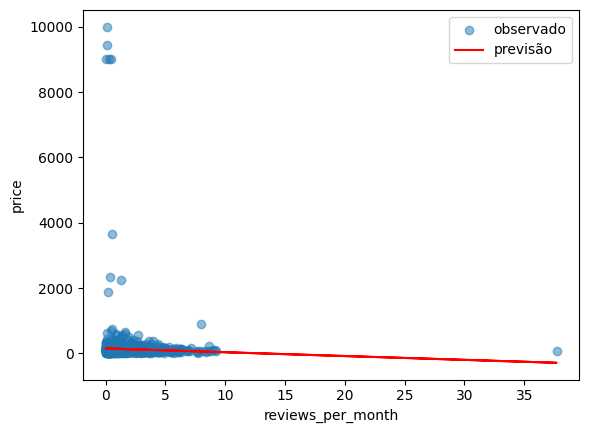

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

dados = df[['reviews_per_month', 'price']].dropna()
X = dados[['reviews_per_month']]
y = dados['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print(f"Coeficiente: {modelo.coef_[0]:.4f}")
print(f"Intercepto: {modelo.intercept_:.4f}")
print(f"R2 (teste): {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

plt.scatter(X_test, y_test, alpha=0.5, label='observado')
plt.plot(X_test, y_pred, color='red', label='previsão')
plt.xlabel('reviews_per_month')
plt.ylabel('price')
plt.legend()
plt.show()